In [3]:
import pandas as pd
import seaborn as sns

## Clean duplicate functions and docstrings

In [11]:
all_data = pd.read_csv('data/Menagerie/data/docstring_code_grades.csv', index_col=0)
all_data = all_data[~all_data['docstring_summary'].isna()]
# all_data['grade'] = all_data['grade'].apply(lambda x: x[0])

In [12]:
all_data.head()

,assignment_number,grade_code,grade,path,docstring,docstring_summary,docstring_tokens,function,function_tokens,line_numbers
0,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,This is what the rabbit does most of the time ...,This is what the rabbit does most of the time ...,"['This', 'is', 'what', 'the', 'rabbit', 'does'...",public void act(List<Animal> newRabbits)\n ...,"['public', 'void', 'act', '(', 'List', '<', 'A...",L60-L81
1,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Increase the age.\nThis could result in the ra...,Increase the age.\nThis could result in the ra...,"['Increase', 'the', 'age', '.', 'This', 'could...",private void incrementAge()\n {\n ag...,"['private', 'void', 'incrementAge', '(', ')', ...",L88-L97
2,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Make this rabbit more hungry. This could resul...,Make this rabbit more hungry. This could resul...,"['Make', 'this', 'rabbit', 'more', 'hungry', '...",private void incrementHunger()\n {\n ...,"['private', 'void', 'incrementHunger', '(', ')...",L102-L108
3,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Look for rabbits adjacent to the current locat...,Look for rabbits adjacent to the current locat...,"['Look', 'for', 'rabbits', 'adjacent', 'to', '...",private Location findFood()\n {\n Fi...,"['private', 'Location', 'findFood', '(', ')', ...",L115-L134
4,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Check whether or not this rabbit is to give bi...,Check whether or not this rabbit is to give bi...,"['Check', 'whether', 'or', 'not', 'this', 'rab...",private void giveBirth(List<Animal> newRabbits...,"['private', 'void', 'giveBirth', '(', 'List', ...",L141-L156


In [14]:
all_data['grade'].value_counts()

grade
A      9673
B+     5902
A-     5359
A+     3985
B      1443
B-      869
A++     459
F       260
C       199
D+       52
D-       52
D        52
C+       49
Name: count, dtype: int64

In [35]:
def transform_values(row):
    grades = set(list(row['grade']))
    output = {'docstring': list(row['docstring'])[0], 'function': list(row['function'])[0], 'grade': str(grades), 'grade_count': len(grades)}
    return pd.Series(output, index=['docstring', 'function', 'grade', 'grade_count'])

def hash_code_docstring_pairs(row):
    code_ds_pair = row['docstring'] + '\n' + row['function']
    return hash(code_ds_pair)

In [36]:
# Hash generated on tokens to remove whitespace causing unique values
all_data['hash'] = all_data.apply(hash_code_docstring_pairs, axis=1)
duplicate_value_df = all_data[['hash', 'grade', 'docstring', 'function']].groupby(['hash']).apply(transform_values)
duplicate_value_df[duplicate_value_df['grade_count'] > 1].head()

/var/folders/1y/6byzw1px62g2f5w7p_rhb6kh0000gn/T/ipykernel_31869/163026546.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duplicate_value_df = all_data[['hash', 'grade', 'docstring', 'function']].groupby(['hash']).apply(transform_values)


,docstring,function,grade,grade_count
hash,,,,
-9201675306568861249,Use the top 16 bits for the row value and the ...,public int hashCode() {\n return (row <...,"{'B+', 'A-', 'B-', 'A'}",4
-9178668662883239887,Get a shuffled list of the free adjacent locat...,public List<Location> getFreeAdjacentLocations...,"{'A+', 'A', 'B'}",3
-9138941864829121006,A sheep can breed if it has reached the breedi...,private boolean canBreed()\n {\n ret...,"{'B+', 'A'}",2
-9136630961645305210,Look for plants adjacent to the current locati...,private Location findFood() {\n Field f...,"{'A+', 'A'}",2
-9110786143726046794,Increment the count for one class of animal.\n...,public void incrementCount(Class actorClass)\n...,"{'A', 'B+'}",2


<Axes: xlabel='grade', ylabel='count'>

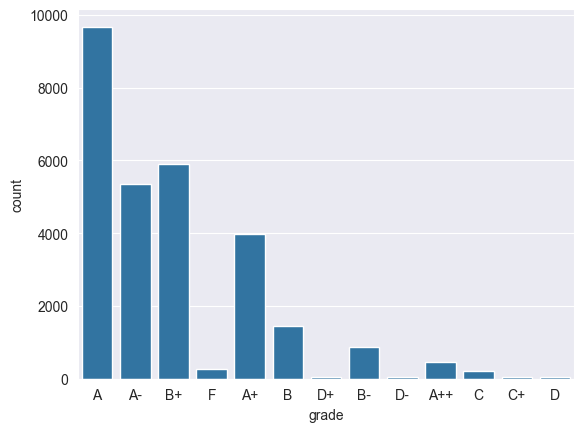

In [37]:
sns.countplot(all_data, x='grade')

### Find Consensus

In [38]:
print(all_data.shape)
all_data.head()

(28354, 13)


,assignment_number,grade_code,grade,path,docstring,docstring_summary,docstring_tokens,function,function_tokens,line_numbers,docstring_hash,code_hash,hash
0,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,This is what the rabbit does most of the time ...,This is what the rabbit does most of the time ...,"['This', 'is', 'what', 'the', 'rabbit', 'does'...",public void act(List<Animal> newRabbits)\n ...,"['public', 'void', 'act', '(', 'List', '<', 'A...",L60-L81,-7549984151395346070,2546514757512326429,-8638063102016899246
1,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Increase the age.\nThis could result in the ra...,Increase the age.\nThis could result in the ra...,"['Increase', 'the', 'age', '.', 'This', 'could...",private void incrementAge()\n {\n ag...,"['private', 'void', 'incrementAge', '(', ')', ...",L88-L97,664236592022653541,-3034784022078136503,3092045474250510778
2,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Make this rabbit more hungry. This could resul...,Make this rabbit more hungry. This could resul...,"['Make', 'this', 'rabbit', 'more', 'hungry', '...",private void incrementHunger()\n {\n ...,"['private', 'void', 'incrementHunger', '(', ')...",L102-L108,-1056833777801479370,5999970022817322933,-1350036207418202643
3,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Look for rabbits adjacent to the current locat...,Look for rabbits adjacent to the current locat...,"['Look', 'for', 'rabbits', 'adjacent', 'to', '...",private Location findFood()\n {\n Fi...,"['private', 'Location', 'findFood', '(', ')', ...",L115-L134,522405395057772105,-184392704877591039,3966206864726036903
4,2,2.0,A,data/anonymised_assignments/18~19/18~19_Submis...,Check whether or not this rabbit is to give bi...,Check whether or not this rabbit is to give bi...,"['Check', 'whether', 'or', 'not', 'this', 'rab...",private void giveBirth(List<Animal> newRabbits...,"['private', 'void', 'giveBirth', '(', 'List', ...",L141-L156,4553988805035933985,-7437503814064365637,-7141431423628399818


In [55]:
def find_consensus(row):
    grades = list(row['grade'])
    
    grade_dict = {}
    
    for grade in grades:
        if grade not in grade_dict.keys():
            grade_dict[grade] = 1
        else:
            grade_dict[grade] += 1
            
    
    grade_consensus = max(grade_dict, key=grade_dict.get)
  
    
    # TODO: If all counts are the same...
    
    output = {'docstring': list(row['docstring'])[0], 'function': list(row['function'])[0], 'grades': grade_dict, 'grade_count': len(grades), 'grade': grade_consensus}
    return pd.Series(output, index=['docstring', 'function', 'grades', 'grade_count', 'grade'])

In [56]:
unique_consensus_df = all_data.groupby('hash').apply(find_consensus)
unique_consensus_df[unique_consensus_df['grade_count'] > 3].head(100)
# unique_consensus_df

/var/folders/1y/6byzw1px62g2f5w7p_rhb6kh0000gn/T/ipykernel_31869/2947905652.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_consensus_df = all_data.groupby('hash').apply(find_consensus)


,docstring,function,grades,grade_count,grade
hash,,,,,
-9201675306568861249,Use the top 16 bits for the row value and the ...,public int hashCode() {\n return (row <...,"{'B-': 1, 'B+': 2, 'A': 1, 'A-': 3}",7,A-
-9138941864829121006,A sheep can breed if it has reached the breedi...,private boolean canBreed()\n {\n ret...,"{'B+': 3, 'A': 2}",5,B+
-9137081015099399470,Get the current age.\n@return The current age.,protected int getAge()\n {\n return ...,{'A': 7},7,A
-9110050523141981510,This method returns the breading probability l...,"@Override\n protected HashMap<Season, Doubl...",{'A': 6},6,A
-8989514752917519848,Adds the foodlevel of the animal,@Override\n protected void addFoodLevel(int...,{'A': 5},5,A
...,...,...,...,...,...
-4048145678469403631,Generate a number representing the number of b...,private int breed()\n {\n int births...,{'A': 5},5,A
-4035108857379258871,This method returns animal's breading age\n@re...,@Override\n protected int getBreedingAge() ...,{'A': 6},6,A
-3886025828939288567,Return the maximum number of births.\n@return ...,public int getMaxLitterSize(){\n return...,{'A': 5},5,A


In [41]:
print(unique_consensus_df.shape)
unique_consensus_df['grade'].value_counts()

(16971, 5)


grade
A      5797
A-     3398
B+     3347
A+     2696
B       834
B-      514
A++     333
C        38
C+       12
F         2
Name: count, dtype: int64

In [12]:
unique_consensus_df.to_csv('data/unique_pairs_only.csv')